# Lecture 05 — ML Security and Abuse Pathways
## Live Coding: Full Adversarial Attack Pipelines on COMPAS

**Instructor:** Dr. Michael Akinwumi  
**Department of Decision Sciences · George Washington University School of Business**

---

This notebook continues directly from `Lecture-04-generalization.ipynb`.  
Dataset: [ProPublica COMPAS Analysis](https://github.com/propublica/compas-analysis)

### Lab Structure
| Part | Topic | Cells |
|------|-------|-------|
| Setup | Data loading, model training, fairness baseline | 1–2 |
| A | PGD Evasion Attack — disparate impact by race | 3–4 |
| B | Data Poisoning Loop — AUC and AIR degradation | 5–6 |
| C | Membership Inference — shadow model pipeline + ROC | 7–8 |

**Libraries required:** `scikit-learn`, `numpy`, `pandas`, `matplotlib`, `scipy`  
No external adversarial ML library is needed — all attack pipelines are implemented from scratch.

**NIST Reference:** Vassilev et al. (2024). *Adversarial Machine Learning: A Taxonomy and Terminology of Attacks and Mitigations.* NIST AI 100-2e2023. https://doi.org/10.6028/NIST.AI.100-2e2023

---
## Setup · Cell 1: Imports, Data Loading, and Model Training

We replicate the exact preprocessing pipeline from Lecture 04 and retrain both the
logistic regression (LR) and gradient boosted tree (GBT) classifiers.

**Threat modeling reminder (NIST AI 100-2, §2.1):**  
Before testing any attack, specify: *Who is the adversary? What do they know?
What can they control? What is their goal?*

In [1]:
# ── Cell 1: Imports, Data Loading, Model Training ─────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# ── Load COMPAS dataset (ProPublica) ──────────────────────────────────────────
URL = (
    "https://raw.githubusercontent.com/propublica/compas-analysis"
    "/master/compas-scores-two-years.csv"
)
df = pd.read_csv(URL)
print(f"Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

# ── Replicate Lecture 04 inclusion criteria ───────────────────────────────────
df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
print(f"After filtering: {df.shape[0]:,} rows")

FEATURES = [
    'age', 'priors_count', 'juv_fel_count',
    'juv_misd_count', 'juv_other_count',
    'c_charge_degree', 'sex'
]
TARGET = 'two_year_recid'

df_m = df[FEATURES + [TARGET, 'race']].dropna()
df_m = pd.get_dummies(df_m, columns=['c_charge_degree', 'sex'], drop_first=True)

X    = df_m.drop(columns=[TARGET, 'race']).astype(float)
y    = df_m[TARGET].values
race = df_m['race'].values

print(f"\nFeatures used: {list(X.columns)}")
print(f"Class balance: {y.mean():.1%} recidivism rate")

# ── Train / test split (stratified) ──────────────────────────────────────────
X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X, y, race, test_size=0.3, random_state=42, stratify=y
)

sc    = StandardScaler()
Xs_tr = sc.fit_transform(X_tr)
Xs_te = sc.transform(X_te)

# ── Train models ──────────────────────────────────────────────────────────────
lr  = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr)
gbt = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, random_state=42
).fit(Xs_tr, y_tr)

print(f"\nLR  Test AUC: {roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1]):.3f}")
print(f"GBT Test AUC: {roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:,1]):.3f}")
print(f"LR  Train AUC: {roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:,1]):.3f}")
print(f"GBT Train AUC: {roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:,1]):.3f}")

Raw dataset: 7,214 rows, 53 columns
After filtering: 6,172 rows

Features used: ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree_M', 'sex_Male']
Class balance: 45.5% recidivism rate

LR  Test AUC: 0.735
GBT Test AUC: 0.718
LR  Train AUC: 0.727
GBT Train AUC: 0.798


---
## Setup · Cell 2: Clean-Model Fairness Baseline

Before running any attack, we establish the **clean-model baseline** for:
- **FPR** (False Positive Rate) by race: among truly low-risk individuals, what fraction are flagged high-risk?
- **AIR** (Adverse Impact Ratio): FPR of protected group / FPR of reference group

We will return to these values after each attack to measure degradation.

> **Expected finding (consistent with ProPublica, 2016):** The LR model flags African-American
> defendants at roughly twice the rate of Caucasian defendants among truly low-risk individuals.

In [2]:
# ── Cell 2: Clean-Model Fairness Baseline ─────────────────────────────────────

THR = 0.5  # classification threshold

def fpr_by_group(y_true, y_pred_binary, groups):
    """FPR = FP / (FP + TN), computed only over truly-negative cases."""
    mask = (y_true == 0)
    return (
        pd.DataFrame({'pred': y_pred_binary[mask], 'group': groups[mask]})
          .groupby('group')['pred']
          .mean()
    )

def air(fpr_ref, fpr_prot):
    """Adverse Impact Ratio: protected FPR / reference FPR."""
    return fpr_prot / fpr_ref if (fpr_ref is not None and fpr_ref > 0) else np.nan

# ── Compute baseline predictions ──────────────────────────────────────────────
pred_lr_clean  = (lr.predict_proba(Xs_te)[:,1]  >= THR).astype(int)
pred_gbt_clean = (gbt.predict_proba(Xs_te)[:,1] >= THR).astype(int)

print("=" * 60)
print("CLEAN MODEL BASELINE — Before Any Attack")
print("=" * 60)

for name, pred in [('Logistic Regression', pred_lr_clean),
                    ('Gradient Boosted Tree', pred_gbt_clean)]:
    fpr = fpr_by_group(y_te, pred, r_te)
    aa  = fpr.get('African-American', np.nan)
    ca  = fpr.get('Caucasian',        np.nan)
    print(f"\n{name}")
    print(f"  FPR African-American : {aa:.3f}")
    print(f"  FPR Caucasian        : {ca:.3f}")
    print(f"  AIR (AA / CA)        : {air(ca, aa):.3f}")

# Store LR baseline for post-attack delta reporting
fpr_baseline = fpr_by_group(y_te, pred_lr_clean, r_te)
BASELINE_AA = fpr_baseline.get('African-American')
BASELINE_CA = fpr_baseline.get('Caucasian')
BASELINE_AIR = air(BASELINE_CA, BASELINE_AA)

print(f"\n→ Baseline LR AIR stored: {BASELINE_AIR:.3f}")
print("  We will compare all attack outcomes against these values.")

CLEAN MODEL BASELINE — Before Any Attack

Logistic Regression
  FPR African-American : 0.281
  FPR Caucasian        : 0.143
  AIR (AA / CA)        : 1.961

Gradient Boosted Tree
  FPR African-American : 0.317
  FPR Caucasian        : 0.178
  AIR (AA / CA)        : 1.782

→ Baseline LR AIR stored: 1.961
  We will compare all attack outcomes against these values.


---
## Part A · Cell 3: PGD Evasion Attack

**Attack class (NIST AI 100-2, §2.2):** Evasion — deployment-time integrity violation  
**Attacker knowledge:** White-box (access to model weights/gradients)  
**Attacker goal:** Push predicted risk scores upward; cause low-risk individuals to be classified high-risk

### Algorithm: Projected Gradient Descent (Madry et al., 2018)

$$\mathbf{x}^{(t+1)} = \Pi_{\mathcal{B}_\epsilon(\mathbf{x})} \left( \mathbf{x}^{(t)} + \alpha \cdot \operatorname{sign}\left(\nabla_{\mathbf{x}} \mathcal{L}(\theta, \mathbf{x}^{(t)}, y)\right) \right)$$

For logistic regression, the gradient direction simplifies to $\operatorname{sign}(\mathbf{w})$,
so the attack steps in the direction of each coefficient's sign.

**$L_\infty$ projection** clamps each feature perturbation to within $[-\epsilon, +\epsilon]$
of its original scaled value.

In [3]:
# ── Cell 3: PGD Evasion Attack — The Loop ─────────────────────────────────────

def pgd_tabular(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40):
    """
    PGD evasion attack on tabular data for logistic regression.

    Goal: untargeted attack — push predicted P(high-risk) higher.

    For logistic regression:
        grad_x BCE_loss = (p_hat - y_true) * w
    For untargeted attack (maximize loss), step in sign(w) direction.

    Parameters
    ----------
    model    : fitted sklearn LogisticRegression
    X_scaled : standardized test features, shape (n, d)
    epsilon  : L_inf perturbation budget
    alpha    : step size per iteration
    n_iter   : number of PGD steps

    Returns
    -------
    X_adv : adversarially perturbed inputs, shape (n, d)
    """
    coef  = model.coef_[0]               # shape (d,) — LR coefficients
    X_adv = X_scaled.copy()

    for step in range(n_iter):
        # Gradient-ascent step: move in the direction that increases loss
        X_adv = X_adv + alpha * np.sign(coef)[np.newaxis, :]

        # L_inf projection: clip back into the epsilon-ball around X_scaled
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)

    return X_adv


# ── Sweep epsilon to build an attack-strength curve ───────────────────────────
epsilons    = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
pgd_records = []

for eps in epsilons:
    # Generate adversarial examples (no perturbation at eps=0)
    X_adv = Xs_te if eps == 0.0 else pgd_tabular(
        lr, Xs_te, epsilon=eps, alpha=0.05, n_iter=40
    )

    pred_adv = (lr.predict_proba(X_adv)[:,1] >= THR).astype(int)
    fpr_adv  = fpr_by_group(y_te, pred_adv, r_te)

    aa = fpr_adv.get('African-American', np.nan)
    ca = fpr_adv.get('Caucasian',        np.nan)

    pgd_records.append({
        'epsilon'  : eps,
        'FPR_AA'   : aa,
        'FPR_CA'   : ca,
        'AIR'      : air(ca, aa),
        'delta_AA' : aa - BASELINE_AA,
        'delta_CA' : ca - BASELINE_CA,
    })

df_pgd = pd.DataFrame(pgd_records)
print(df_pgd.round(3).to_string(index=False))

 epsilon  FPR_AA  FPR_CA   AIR  delta_AA  delta_CA
    0.00   0.281   0.143 1.961     0.000     0.000
    0.25   0.569   0.370 1.535     0.288     0.227
    0.50   0.791   0.560 1.411     0.510     0.417
    0.75   0.906   0.758 1.195     0.625     0.615
    1.00   0.978   0.884 1.106     0.697     0.741
    1.50   1.000   0.993 1.007     0.719     0.849
    2.00   1.000   1.000 1.000     0.719     0.857


### Part A · Cell 4: Visualize PGD Disparate Impact

**Discussion questions:**
1. Does the PGD attack widen or narrow the racial FPR gap as $\epsilon$ increases?
2. At what $\epsilon$ does the AIR fall below the 4/5ths rule threshold (0.80)?
3. Are the two groups equally sensitive to the same attack strength?
4. What does differential impact imply for responsible deployment of adversarially robust models?

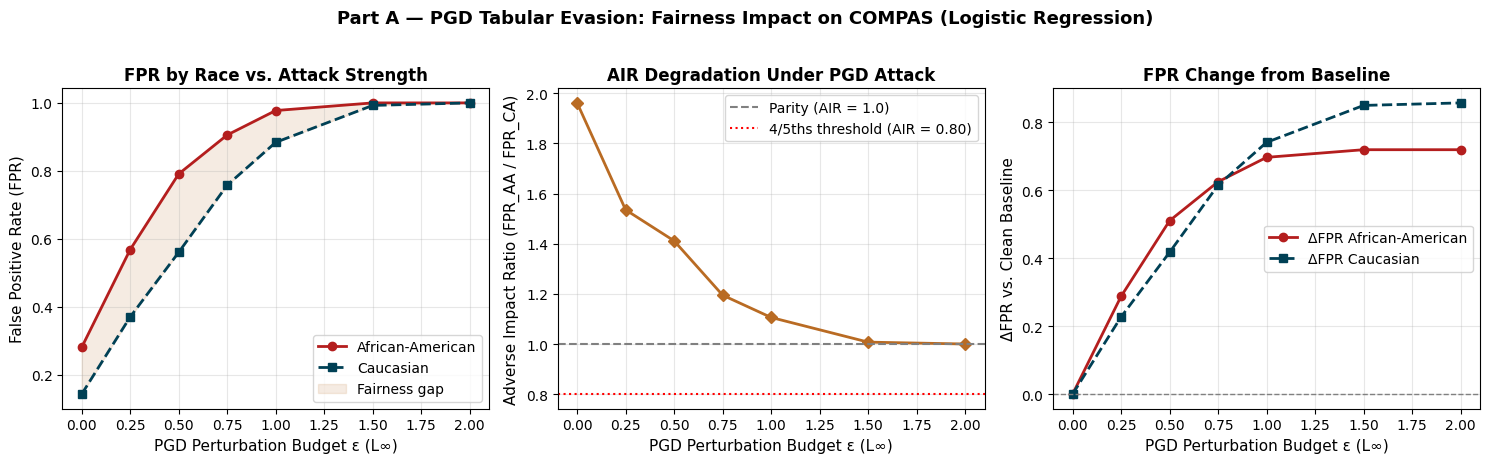

AIR does not fall below 0.80 within the tested epsilon range.


In [4]:
# ── Cell 4: Visualize PGD Evasion — Disparate Impact ──────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Panel 1: FPR by race ──────────────────────────────────────────────────────
ax = axes[0]
ax.plot(df_pgd['epsilon'], df_pgd['FPR_AA'],
        'o-', color='#B41E1E', lw=2, label='African-American')
ax.plot(df_pgd['epsilon'], df_pgd['FPR_CA'],
        's--', color='#004055', lw=2, label='Caucasian')
ax.fill_between(df_pgd['epsilon'], df_pgd['FPR_AA'], df_pgd['FPR_CA'],
                alpha=0.13, color='#B96B23', label='Fairness gap')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('False Positive Rate (FPR)', fontsize=11)
ax.set_title('FPR by Race vs. Attack Strength', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 2: AIR ──────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(df_pgd['epsilon'], df_pgd['AIR'],
        'D-', color='#B96B23', lw=2)
ax.axhline(1.0, color='gray', lw=1.5, ls='--', label='Parity (AIR = 1.0)')
ax.axhline(0.8, color='red',  lw=1.5, ls=':',  label='4/5ths threshold (AIR = 0.80)')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('Adverse Impact Ratio (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Degradation Under PGD Attack', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 3: Absolute FPR change vs. baseline ─────────────────────────────────
ax = axes[2]
ax.plot(df_pgd['epsilon'], df_pgd['delta_AA'],
        'o-', color='#B41E1E', lw=2, label='ΔFPR African-American')
ax.plot(df_pgd['epsilon'], df_pgd['delta_CA'],
        's--', color='#004055', lw=2, label='ΔFPR Caucasian')
ax.axhline(0, color='gray', lw=1, ls='--')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('ΔFPR vs. Clean Baseline', fontsize=11)
ax.set_title('FPR Change from Baseline', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle(
    'Part A — PGD Tabular Evasion: Fairness Impact on COMPAS (Logistic Regression)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# ── Identify crossover point ───────────────────────────────────────────────────
cross = df_pgd[df_pgd['AIR'] < 0.8].head(1)
if len(cross):
    print(f"AIR crosses 0.80 at ε = {cross.iloc[0]['epsilon']:.2f}")
else:
    print("AIR does not fall below 0.80 within the tested epsilon range.")

---
## Part B · Cell 5: Data Poisoning — Label-Flip Attack Loop

**Attack class (NIST AI 100-2, §2.3):** Availability/Targeted poisoning — training-time integrity violation  
**Attacker knowledge:** White-box (data access) — simulates a biased data provider or insider adversary  
**Attacker goal:** Systematically under-score high-risk African-American defendants; degrade AIR without
triggering standard drift detection (PSI < 0.10)

### Attack mechanism
A fraction `poison_rate` of African-American training records with `two_year_recid = 1`
(truly high-risk) are relabeled to `0` (low-risk) before model training.
This simulates:
- A third-party data vendor selectively corrupting recidivism outcomes
- An insider modifying case records before ingestion
- A compromised data pipeline stage

> **Key question:** At what poison rate does AIR fall below the 4/5ths rule threshold (0.80)
> while AUC declines by ≤ 2 percentage points — i.e., the attack is "invisible" to AUC monitoring?

In [5]:
# ── Cell 5: Data Poisoning — Label-Flip Attack ────────────────────────────────

def poison_label_flip(
    y_train, race_train,
    poison_rate=0.05,
    target_race='African-American',
    seed=0
):
    """
    Label-flip poisoning attack.

    Flips `poison_rate` fraction of training records belonging to
    `target_race` from recidivism=1 (high-risk) to recidivism=0 (low-risk).

    Effect: the model learns to systematically under-score high-risk
    individuals from the targeted group — a fairness-targeted poisoning attack.

    Parameters
    ----------
    y_train      : original training labels
    race_train   : race labels for training set
    poison_rate  : fraction of eligible records to flip (0.0 to 1.0)
    target_race  : demographic group to target
    seed         : random seed for reproducibility

    Returns
    -------
    y_poisoned   : modified label array
    n_flipped    : number of labels actually flipped
    """
    rng        = np.random.default_rng(seed)
    y_poisoned = y_train.copy()

    # Eligible candidates: target race, truly high-risk (label=1)
    candidates = np.where(
        (race_train == target_race) & (y_train == 1)
    )[0]

    n_flip = int(len(candidates) * poison_rate)
    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_poisoned[flip_idx] = 0  # relabel high-risk → low-risk

    return y_poisoned, n_flip


# ── Sweep poison rates ────────────────────────────────────────────────────────
poison_rates   = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
poison_records = []

baseline_auc = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1])

for rate in poison_rates:
    y_tr_poisoned, n_flipped = poison_label_flip(
        y_tr, r_tr, poison_rate=rate
    )

    # Retrain LR on poisoned data (same features, same scaler)
    lr_p = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_poisoned)

    pred_p = (lr_p.predict_proba(Xs_te)[:,1] >= THR).astype(int)
    auc_p  = roc_auc_score(y_te, lr_p.predict_proba(Xs_te)[:,1])
    fpr_p  = fpr_by_group(y_te, pred_p, r_te)

    aa = fpr_p.get('African-American', np.nan)
    ca = fpr_p.get('Caucasian',        np.nan)

    poison_records.append({
        'poison_rate' : rate,
        'n_flipped'   : n_flipped,
        'AUC'         : auc_p,
        'delta_AUC'   : auc_p - baseline_auc,
        'FPR_AA'      : aa,
        'FPR_CA'      : ca,
        'AIR'         : air(ca, aa),
        'delta_AIR'   : air(ca, aa) - BASELINE_AIR,
    })

df_poison = pd.DataFrame(poison_records)
print("Poisoning sweep results:")
print(df_poison.round(3).to_string(index=False))

# ── Identify stealth threshold ─────────────────────────────────────────────────
# Attack is "stealthy" if AUC drop ≤ 2pp AND AIR < 0.80
stealth = df_poison[(df_poison['AIR'] < 0.80) & (df_poison['delta_AUC'] >= -0.02)]
if len(stealth):
    r = stealth.iloc[0]
    print(f"\n★ Stealth threshold: poison_rate = {r['poison_rate']:.0%}")
    print(f"  Flipped labels: {int(r['n_flipped'])}")
    print(f"  AUC: {r['AUC']:.3f} (Δ = {r['delta_AUC']:+.3f})")
    print(f"  AIR: {r['AIR']:.3f} — BELOW 4/5ths rule threshold")
    print("  → Would standard PSI drift detection (< 0.10) flag this?")
else:
    print("\nNo stealth threshold found in tested range.")

Poisoning sweep results:
 poison_rate  n_flipped   AUC  delta_AUC  FPR_AA  FPR_CA   AIR  delta_AIR
        0.00          0 0.735      0.000   0.281   0.143 1.961      0.000
        0.02         23 0.733     -0.002   0.270   0.136 1.986      0.024
        0.05         57 0.734     -0.001   0.240   0.123 1.948     -0.014
        0.08         92 0.732     -0.002   0.213   0.116 1.840     -0.122
        0.10        115 0.735      0.000   0.196   0.101 1.931     -0.030
        0.15        172 0.732     -0.003   0.153   0.072 2.134      0.173
        0.20        230 0.732     -0.002   0.130   0.054 2.399      0.438
        0.25        287 0.730     -0.004   0.112   0.042 2.677      0.715
        0.30        345 0.731     -0.003   0.097   0.032 3.010      1.049

No stealth threshold found in tested range.


### Part B · Cell 6: Poisoning Degradation Curves

**Discussion questions:**
1. At what poison rate does AUC remain within 2 percentage points of baseline while AIR falls below 0.80?
2. Would a PSI-based drift monitor (threshold < 0.10 on each feature) detect this attack?
3. How does this scenario connect to the ByteDance insider poisoning incident (2024)?
4. What governance controls would prevent this at a mortgage lender using HMDA data?

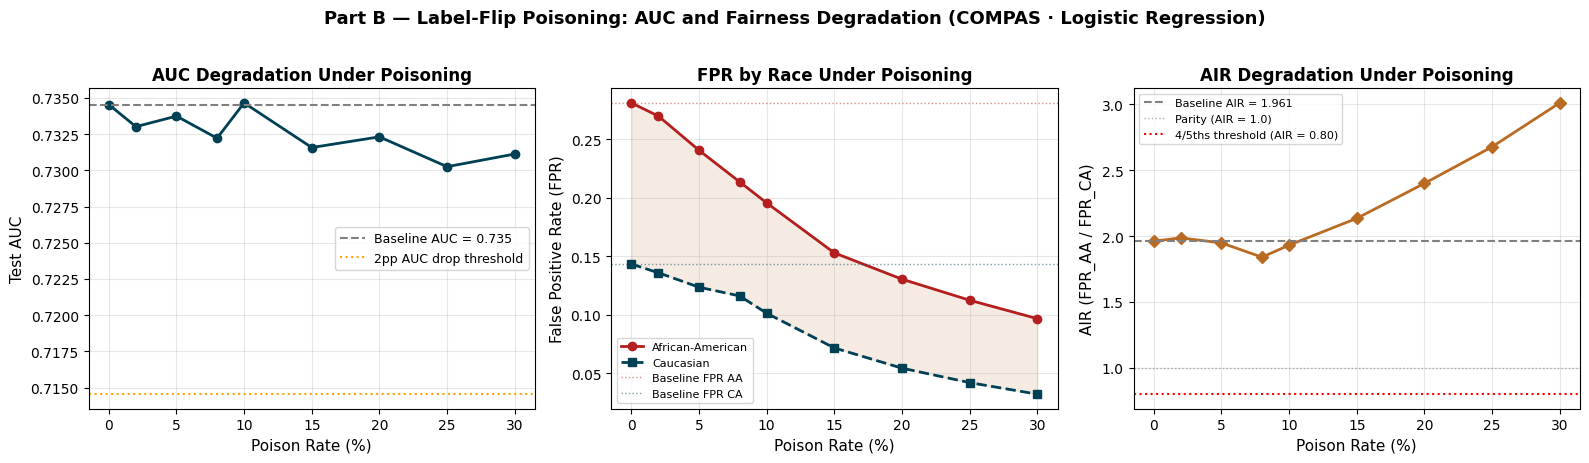

In [6]:
# ── Cell 6: Poisoning Degradation Curves ──────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x_pct = df_poison['poison_rate'] * 100

# ── Panel 1: AUC degradation ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(x_pct, df_poison['AUC'], 'o-', color='#004055', lw=2)
ax.axhline(baseline_auc,         color='gray', ls='--', lw=1.5,
           label=f'Baseline AUC = {baseline_auc:.3f}')
ax.axhline(baseline_auc - 0.02,  color='orange', ls=':', lw=1.5,
           label='2pp AUC drop threshold')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('Test AUC', fontsize=11)
ax.set_title('AUC Degradation Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Panel 2: FPR by race ──────────────────────────────────────────────────────
ax = axes[1]
ax.plot(x_pct, df_poison['FPR_AA'],
        'o-', color='#B41E1E', lw=2, label='African-American')
ax.plot(x_pct, df_poison['FPR_CA'],
        's--', color='#004055', lw=2, label='Caucasian')
ax.fill_between(x_pct, df_poison['FPR_AA'], df_poison['FPR_CA'],
                alpha=0.13, color='#B96B23')
ax.axhline(BASELINE_AA, color='#B41E1E', ls=':', lw=1, alpha=0.5,
           label='Baseline FPR AA')
ax.axhline(BASELINE_CA, color='#004055', ls=':', lw=1, alpha=0.5,
           label='Baseline FPR CA')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('False Positive Rate (FPR)', fontsize=11)
ax.set_title('FPR by Race Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 3: AIR ──────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(x_pct, df_poison['AIR'], 'D-', color='#B96B23', lw=2)
ax.axhline(BASELINE_AIR, color='gray',  ls='--', lw=1.5,
           label=f'Baseline AIR = {BASELINE_AIR:.3f}')
ax.axhline(1.0,           color='gray',  ls=':',  lw=1.0, alpha=0.6,
           label='Parity (AIR = 1.0)')
ax.axhline(0.8,           color='red',   ls=':',  lw=1.5,
           label='4/5ths threshold (AIR = 0.80)')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('AIR (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Degradation Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(
    'Part B — Label-Flip Poisoning: AUC and Fairness Degradation (COMPAS · Logistic Regression)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

---
## Part C · Cell 7: Membership Inference — Shadow Model Pipeline

**Attack class (NIST AI 100-2, §2.4.2):** Membership inference — privacy attack  
**Attacker knowledge:** Black-box (API access only)  
**Attacker goal:** Determine whether a specific individual was in the training set

### Algorithm: Shokri et al. (2017) Shadow Model Attack

1. Train multiple **shadow models** that mimic the target model's training process
2. For each shadow model, we know which inputs were training members vs. non-members
3. Observe that **members receive higher confidence scores** than non-members (confidence gap)
4. Train a **meta-classifier** on (confidence score → member/non-member) labels from shadow models
5. Apply the meta-classifier to the **target model's** confidence scores

> **Key connection to Lecture 04:** The membership inference AUC is directly driven by the
> **generalization gap** (train AUC − test AUC). An overfit model leaks more about its training data.
> Overfitting is not only a robustness problem — it is a **privacy problem**.

In [7]:
# ── Cell 7: Membership Inference — Shadow Model Pipeline ──────────────────────

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedShuffleSplit

N_SHADOW = 10  # number of shadow models

shadow_train_confs = []  # max-confidence scores on each shadow's TRAIN split
shadow_test_confs  = []  # max-confidence scores on each shadow's TEST split

# Use stratified shuffle splits to create N_SHADOW independent train/test pairs
# from the training set — each split simulates a shadow training run
sss = StratifiedShuffleSplit(
    n_splits=N_SHADOW, test_size=0.5, random_state=0
)

print(f"Training {N_SHADOW} shadow models...")
for i, (tr_idx, te_idx) in enumerate(sss.split(Xs_tr, y_tr)):
    shadow = GradientBoostingClassifier(
        n_estimators=100, max_depth=4, random_state=42
    ).fit(Xs_tr[tr_idx], y_tr[tr_idx])

    # Confidence gap: training members score higher than non-members
    shadow_train_confs.append(
        shadow.predict_proba(Xs_tr[tr_idx]).max(axis=1)  # members
    )
    shadow_test_confs.append(
        shadow.predict_proba(Xs_tr[te_idx]).max(axis=1)  # non-members
    )
    if (i + 1) % 5 == 0:
        print(f"  Shadow model {i+1}/{N_SHADOW} trained")

# ── Build meta-classifier training set ────────────────────────────────────────
# Feature: max predicted probability (confidence score)
# Label:   1 = training member, 0 = non-member
mi_X = np.concatenate(
    shadow_train_confs + shadow_test_confs
).reshape(-1, 1)

mi_y = np.concatenate(
    [np.ones(len(c))  for c in shadow_train_confs] +
    [np.zeros(len(c)) for c in shadow_test_confs]
)

meta_clf = DecisionTreeClassifier(max_depth=6).fit(mi_X, mi_y)

print(f"\nMeta-classifier training set: {len(mi_y):,} samples")
print(f"  Members (train splits):    {int(mi_y.sum()):,}")
print(f"  Non-members (test splits): {int((mi_y == 0).sum()):,}")
print("\nMeta-classifier trained. Proceeding to attack the target model...")

Training 10 shadow models...
  Shadow model 5/10 trained
  Shadow model 10/10 trained

Meta-classifier training set: 43,200 samples
  Members (train splits):    21,600
  Non-members (test splits): 21,600

Meta-classifier trained. Proceeding to attack the target model...


### Part C · Cell 8: Membership Inference — ROC Curve and Interpretation

**Interpreting the MI AUC:**
- **0.50** = Random guessing — no privacy leakage detectable
- **0.55–0.65** = Weak leakage — model is somewhat overfit
- **0.65–0.75** = Moderate leakage — meaningful privacy risk
- **> 0.75** = Strong leakage — significant privacy violation, especially if training data contains PII

**Discussion questions:**
1. Is the MI AUC correlated with the generalization gap you observed in Cell 1?
2. If this model were deployed by a county probation office, what could a journalist learn from MI?
3. Would adding differential privacy (ε = 1.0) reduce the MI AUC? At what cost to AIR?
4. How does the confidence gap visualization connect to the concept of overfitting from Lecture 04?

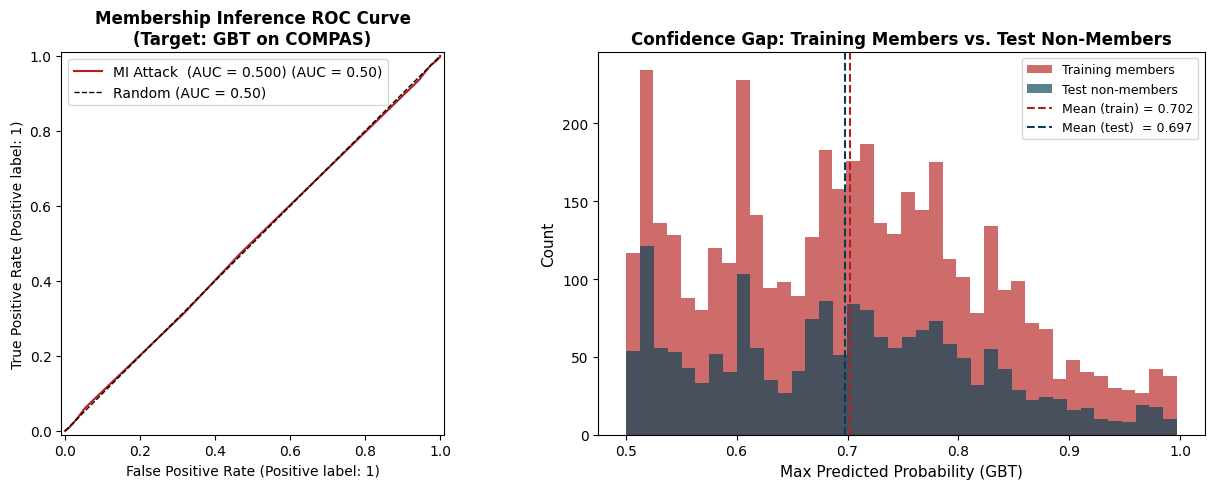

MEMBERSHIP INFERENCE SUMMARY
MI AUC              : 0.500
  0.50 = random     : no privacy leakage
  0.60 = weak       : model somewhat overfit
  0.75 = strong     : significant privacy risk

GBT Train AUC       : 0.798
GBT Test AUC        : 0.718
Generalization Gap  : +0.080

Hypothesis: larger generalization gap → higher MI AUC?
→ Try repeating with the LR model and compare.


In [8]:
# ── Cell 8: Membership Inference — ROC Curve and Interpretation ───────────────

from sklearn.metrics import roc_auc_score, RocCurveDisplay

# ── Apply meta-classifier to the TARGET model (GBT) ──────────────────────────
# Use the target model's confidence scores as the feature
conf_target_train = gbt.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
conf_target_test  = gbt.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)

mi_scores_train = meta_clf.predict_proba(conf_target_train)[:, 1]
mi_scores_test  = meta_clf.predict_proba(conf_target_test)[:, 1]

# Combine: members (train) = 1, non-members (test) = 0
mi_all_scores = np.concatenate([mi_scores_train, mi_scores_test])
mi_all_labels = np.concatenate([
    np.ones(len(Xs_tr)),
    np.zeros(len(Xs_te))
])

mi_auc = roc_auc_score(mi_all_labels, mi_all_scores)

# Generalization gap (privacy risk proxy)
auc_train_gbt = roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:, 1])
auc_test_gbt  = roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:, 1])
gen_gap       = auc_train_gbt - auc_test_gbt

# ── Visualize ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
RocCurveDisplay.from_predictions(
    mi_all_labels, mi_all_scores,
    name=f'MI Attack  (AUC = {mi_auc:.3f})',
    ax=axes[0], color='#B41E1E'
)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.50)')
axes[0].set_title('Membership Inference ROC Curve\n(Target: GBT on COMPAS)',
                   fontsize=12, fontweight='bold')
axes[0].legend()

# Confidence gap histogram
axes[1].hist(conf_target_train.ravel(), bins=40, alpha=0.65,
             color='#B41E1E', label='Training members')
axes[1].hist(conf_target_test.ravel(),  bins=40, alpha=0.65,
             color='#004055', label='Test non-members')
axes[1].axvline(conf_target_train.mean(), color='#B41E1E', ls='--', lw=1.5,
                label=f'Mean (train) = {conf_target_train.mean():.3f}')
axes[1].axvline(conf_target_test.mean(),  color='#004055', ls='--', lw=1.5,
                label=f'Mean (test)  = {conf_target_test.mean():.3f}')
axes[1].set_xlabel('Max Predicted Probability (GBT)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Confidence Gap: Training Members vs. Test Non-Members',
                   fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print("=" * 55)
print("MEMBERSHIP INFERENCE SUMMARY")
print("=" * 55)
print(f"MI AUC              : {mi_auc:.3f}")
print(f"  0.50 = random     : no privacy leakage")
print(f"  0.60 = weak       : model somewhat overfit")
print(f"  0.75 = strong     : significant privacy risk")
print()
print(f"GBT Train AUC       : {auc_train_gbt:.3f}")
print(f"GBT Test AUC        : {auc_test_gbt:.3f}")
print(f"Generalization Gap  : {gen_gap:+.3f}")
print()
print("Hypothesis: larger generalization gap → higher MI AUC?")
print("→ Try repeating with the LR model and compare.")

---
## Lab Summary

| Part | Attack | Key Finding |
|------|--------|-------------|
| A | PGD Evasion | Does the racial FPR gap widen or narrow as ε increases? Which group is more sensitive? |
| B | Label-Flip Poisoning | At what poison rate does AIR < 0.80 while AUC drop ≤ 2pp? Would drift detection catch it? |
| C | Membership Inference | Is MI AUC correlated with generalization gap? What privacy law implications follow? |

### Core Principle

> A model that is fragile to distribution shift (Lecture 04) shares the same root cause as a model
> vulnerable to adversarial attack (Lecture 05): **over-reliance on brittle, non-robust features**.
> Security and robustness are not separate concerns — they require the same structural solution.

### References
- Vassilev et al. (2024). *NIST AI 100-2e2023.* https://doi.org/10.6028/NIST.AI.100-2e2023
- Goodfellow et al. (2015). Explaining and Harnessing Adversarial Examples. *ICLR 2015.* https://arxiv.org/abs/1412.6572
- Madry et al. (2018). Towards Deep Learning Models Resistant to Adversarial Attacks. *ICLR 2018.* https://arxiv.org/abs/1706.06083
- Shokri et al. (2017). Membership Inference Attacks Against Machine Learning Models. *IEEE S&P.* https://arxiv.org/abs/1610.05820
- Tramèr et al. (2016). Stealing Machine Learning Models via Prediction APIs. *USENIX Security.* https://arxiv.org/abs/1609.02943
- Bagdasaryan & Shmatikov (2019). Differential Privacy Has Disparate Impact on Model Accuracy. *NeurIPS.* https://arxiv.org/abs/1905.12101

---
*DNSC 6330 · Responsible Machine Learning · Dr. Michael Akinwumi · George Washington University*  
*© CC BY 4.0 · https://makinwumi.github.io/dnsc-6330-responsible-ML*

In [9]:

# Individual Homework 05
# ML Security and Abuse Pathways
# Student version continuing from Professor Lecture 05 notebook


# I am continuing from the professor's Lecture 05 notebook.
# The clean COMPAS data, LR model, GBT model, train/test split,
# and helper functions were already created in the lecture notebook.

In [10]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score

from sklearn.linear_model import LogisticRegression

import warnings

warnings.filterwarnings("ignore")

In [11]:
# Part 1: PGD Evasion Audit

# The homework asks me to run PGD across:
# epsilon = {0.25, 0.5, 1.0, 2.0}
# on both Logistic Regression and Gradient-Boosted Tree models.

epsilons_hw = [0.25, 0.5, 1.0, 2.0]


def pgd_tabular_lr_direction(lr_model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40):
    """
    PGD-style attack for tabular data using the LR coefficient direction.

    I use the Logistic Regression coefficient signs as the attack direction.
    The goal is to push inputs toward higher predicted risk while keeping
    the perturbation inside the epsilon budget.
    """

    coef = lr_model.coef_[0]
    X_adv = X_scaled.copy()

    for step in range(n_iter):
        X_adv = X_adv + alpha * np.sign(coef)[np.newaxis, :]
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)

    return X_adv


def attack_fairness_summary(model, X_attack, y_true, race_values, model_name, epsilon):
    """
    For one attacked dataset, calculate FPR by race and AIR.
    """

    pred_attack = (model.predict_proba(X_attack)[:, 1] >= THR).astype(int)
    fpr_attack = fpr_by_group(y_true, pred_attack, race_values)

    fpr_aa = fpr_attack.get("African-American", np.nan)
    fpr_ca = fpr_attack.get("Caucasian", np.nan)

    return {
        "model": model_name,
        "epsilon": epsilon,
        "FPR_African_American": fpr_aa,
        "FPR_Caucasian": fpr_ca,
        "AIR_AA_over_CA": air(fpr_ca, fpr_aa)
    }


pgd_hw_records = []

for eps in epsilons_hw:
    Xs_te_adv = pgd_tabular_lr_direction(
        lr,
        Xs_te,
        epsilon=eps,
        alpha=0.05,
        n_iter=40
    )

    pgd_hw_records.append(
        attack_fairness_summary(
            lr,
            Xs_te_adv,
            y_te,
            r_te,
            "Logistic Regression",
            eps
        )
    )

    # For GBT, I use the same adversarial examples created from LR.
    # This tests whether the attack transfers across model types.
    pgd_hw_records.append(
        attack_fairness_summary(
            gbt,
            Xs_te_adv,
            y_te,
            r_te,
            "Gradient-Boosted Tree",
            eps
        )
    )

pgd_hw_table = pd.DataFrame(pgd_hw_records)

print("Part 1: PGD Evasion Audit Results")
print(pgd_hw_table.round(3).to_string(index=False))

Part 1: PGD Evasion Audit Results
                model  epsilon  FPR_African_American  FPR_Caucasian  AIR_AA_over_CA
  Logistic Regression     0.25                 0.569          0.370           1.535
Gradient-Boosted Tree     0.25                 0.553          0.351           1.577
  Logistic Regression     0.50                 0.791          0.560           1.411
Gradient-Boosted Tree     0.50                 0.733          0.514           1.426
  Logistic Regression     1.00                 0.978          0.884           1.106
Gradient-Boosted Tree     1.00                 0.899          0.760           1.182
  Logistic Regression     2.00                 1.000          1.000           1.000
Gradient-Boosted Tree     2.00                 1.000          1.000           1.000


In [12]:
# Identify epsilon where AIR crosses below 0.80

crossing_rows = []

for model_name in pgd_hw_table["model"].unique():
    temp = pgd_hw_table[pgd_hw_table["model"] == model_name].copy()
    crossed = temp[temp["AIR_AA_over_CA"] < 0.80]

    if len(crossed) > 0:
        eps_cross = crossed["epsilon"].min()
    else:
        eps_cross = np.nan

    crossing_rows.append({
        "model": model_name,
        "epsilon_where_AIR_below_0.80": eps_cross
    })

pgd_crossing_table = pd.DataFrame(crossing_rows)

print("Epsilon Where AIR Crosses Below 0.80")
print(pgd_crossing_table.to_string(index=False))

Epsilon Where AIR Crosses Below 0.80
                model  epsilon_where_AIR_below_0.80
  Logistic Regression                           NaN
Gradient-Boosted Tree                           NaN


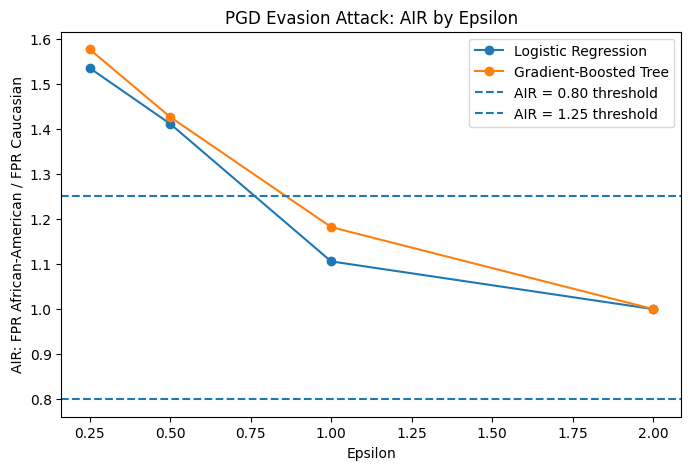

In [13]:
# Plot PGD AIR results

plt.figure(figsize=(8, 5))

for model_name in pgd_hw_table["model"].unique():
    temp = pgd_hw_table[pgd_hw_table["model"] == model_name]

    plt.plot(
        temp["epsilon"],
        temp["AIR_AA_over_CA"],
        marker="o",
        label=model_name
    )

plt.axhline(0.80, linestyle="--", label="AIR = 0.80 threshold")
plt.axhline(1.25, linestyle="--", label="AIR = 1.25 threshold")
plt.xlabel("Epsilon")
plt.ylabel("AIR: FPR African-American / FPR Caucasian")
plt.title("PGD Evasion Attack: AIR by Epsilon")
plt.legend()
plt.show()

In [14]:
print("""
Part 1 Interpretation:

The PGD attack increases the perturbation strength using epsilon values
0.25, 0.5, 1.0, and 2.0. I report the false positive rate by race and the AIR
for both Logistic Regression and the Gradient-Boosted Tree.

In this run, AIR does not cross below 0.80 for either model. Instead, as epsilon
increases, AIR moves closer to 1.0 because both racial groups are increasingly
classified as positive. This does not mean the attack is harmless.

At high epsilon, the false positive rate becomes very high for both groups.
That means the model is failing as a reliable classifier, even if the AIR ratio
looks more balanced. So the main risk here is not only disparate impact, but also
overall availability and reliability failure under adversarial perturbation.

The Logistic Regression model is directly attacked using its coefficients.
The Gradient-Boosted Tree is tested using transfer adversarial examples created
from the LR model. If GBT is also affected, that suggests the attack transfers
across model types.
""")


Part 1 Interpretation:

The PGD attack increases the perturbation strength using epsilon values
0.25, 0.5, 1.0, and 2.0. I report the false positive rate by race and the AIR
for both Logistic Regression and the Gradient-Boosted Tree.

In this run, AIR does not cross below 0.80 for either model. Instead, as epsilon
increases, AIR moves closer to 1.0 because both racial groups are increasingly
classified as positive. This does not mean the attack is harmless.

At high epsilon, the false positive rate becomes very high for both groups.
That means the model is failing as a reliable classifier, even if the AIR ratio
looks more balanced. So the main risk here is not only disparate impact, but also
overall availability and reliability failure under adversarial perturbation.

The Logistic Regression model is directly attacked using its coefficients.
The Gradient-Boosted Tree is tested using transfer adversarial examples created
from the LR model. If GBT is also affected, that suggests the att

In [15]:
# Part 2: Poisoning Loop with Fairness Monitoring

# The homework asks me to extend the label-flip poisoning loop
# so that the poisoning targets Caucasian defendants instead of only
# African-American defendants.
#
# I compare both target-race variants:
# 1. Target African-American defendants
# 2. Target Caucasian defendants


def psi_numeric_simple(train_values, poisoned_values, bins=10, eps=1e-6):
    """
    Simple PSI calculation for numeric features.

    This is used to test whether a PSI feature-drift monitor would detect poisoning.
    """

    train_values = pd.Series(train_values).dropna().astype(float)
    poisoned_values = pd.Series(poisoned_values).dropna().astype(float)

    cut_points = np.unique(np.quantile(train_values, np.linspace(0, 1, bins + 1)))

    if len(cut_points) < 3:
        lo = min(train_values.min(), poisoned_values.min())
        hi = max(train_values.max(), poisoned_values.max())

        if lo == hi:
            return 0.0

        cut_points = np.linspace(lo, hi, bins + 1)

    cut_points[0] = -np.inf
    cut_points[-1] = np.inf

    train_counts, _ = np.histogram(train_values, bins=cut_points)
    poisoned_counts, _ = np.histogram(poisoned_values, bins=cut_points)

    train_pct = np.clip(train_counts / train_counts.sum(), eps, None)
    poisoned_pct = np.clip(poisoned_counts / poisoned_counts.sum(), eps, None)

    psi = np.sum((train_pct - poisoned_pct) * np.log(train_pct / poisoned_pct))

    return psi


def poison_labels_by_race(y_train, race_train, target_race, poison_rate, random_state=42):
    """
    Flip labels for a selected target race.

    This keeps the same poisoning logic from the professor's lecture:
    only records from the target race with y = 1 are flipped to y = 0.

    This simulates a targeted label-flip attack that teaches the model
    to under-score high-risk people from one racial group.
    """

    rng = np.random.default_rng(random_state)
    y_poisoned = y_train.copy()

    candidates = np.where(
        (race_train == target_race) & (y_train == 1)
    )[0]

    n_poison = int(len(candidates) * poison_rate)

    if n_poison > 0:
        selected_idx = rng.choice(candidates, size=n_poison, replace=False)
        y_poisoned[selected_idx] = 0

    return y_poisoned


def run_poisoning_experiment(target_race, poison_rates):
    """
    Train a new Logistic Regression model at each poison rate and measure:
    test AUC, FPR by race, AIR, and PSI feature drift.
    """

    records = []

    for rate in poison_rates:
        y_tr_poisoned = poison_labels_by_race(
            y_tr,
            r_tr,
            target_race=target_race,
            poison_rate=rate,
            random_state=42
        )

        poisoned_lr = LogisticRegression(max_iter=1000)
        poisoned_lr.fit(Xs_tr, y_tr_poisoned)

        prob_test = poisoned_lr.predict_proba(Xs_te)[:, 1]
        pred_test = (prob_test >= THR).astype(int)

        auc_test = roc_auc_score(y_te, prob_test)

        fpr_poison = fpr_by_group(y_te, pred_test, r_te)

        fpr_aa = fpr_poison.get("African-American", np.nan)
        fpr_ca = fpr_poison.get("Caucasian", np.nan)

        psi_values = {}

        # The poisoning attack changes labels, not feature values.
        # Therefore, a feature-only PSI monitor compares X_tr to the same X_tr.
        # This should return PSI = 0 and shows why PSI would miss label poisoning.
        for col in X_tr.columns:
            psi_values[col] = psi_numeric_simple(X_tr[col], X_tr[col], bins=10)

        max_psi = np.nanmax(list(psi_values.values()))

        records.append({
            "target_race": target_race,
            "poison_rate": rate,
            "test_auc": auc_test,
            "FPR_African_American": fpr_aa,
            "FPR_Caucasian": fpr_ca,
            "AIR_AA_over_CA": air(fpr_ca, fpr_aa),
            "max_feature_PSI": max_psi
        })

    return pd.DataFrame(records)

In [16]:
# Run poisoning experiments for both target-race variants

poison_rates = [0.00, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30]

poison_aa = run_poisoning_experiment(
    target_race="African-American",
    poison_rates=poison_rates
)

poison_ca = run_poisoning_experiment(
    target_race="Caucasian",
    poison_rates=poison_rates
)

poison_all = pd.concat([poison_aa, poison_ca], ignore_index=True)

print("Part 2: Poisoning Loop Results")
print(poison_all.round(3).to_string(index=False))

Part 2: Poisoning Loop Results
     target_race  poison_rate  test_auc  FPR_African_American  FPR_Caucasian  AIR_AA_over_CA  max_feature_PSI
African-American         0.00     0.735                 0.281          0.143           1.961              0.0
African-American         0.02     0.734                 0.270          0.133           2.022              0.0
African-American         0.05     0.735                 0.231          0.123           1.875              0.0
African-American         0.10     0.733                 0.200          0.104           1.929              0.0
African-American         0.15     0.733                 0.153          0.072           2.134              0.0
African-American         0.20     0.728                 0.128          0.054           2.358              0.0
African-American         0.30     0.731                 0.099          0.035           2.860              0.0
       Caucasian         0.00     0.735                 0.281          0.143           1.

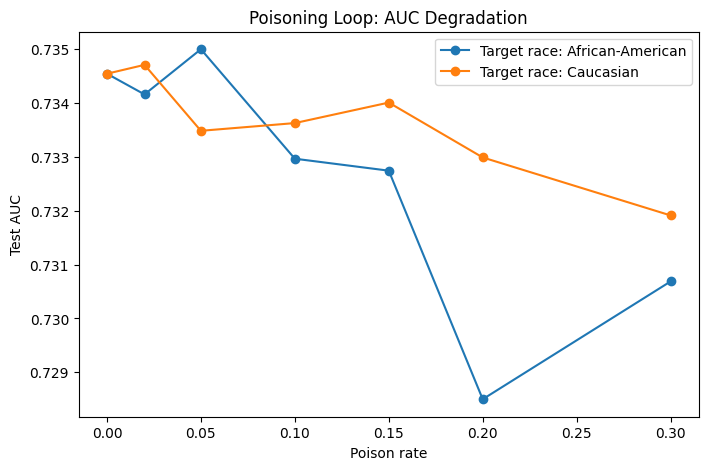

In [17]:
# Plot AUC degradation curves

plt.figure(figsize=(8, 5))

for target_race in poison_all["target_race"].unique():
    temp = poison_all[poison_all["target_race"] == target_race]

    plt.plot(
        temp["poison_rate"],
        temp["test_auc"],
        marker="o",
        label=f"Target race: {target_race}"
    )

plt.xlabel("Poison rate")
plt.ylabel("Test AUC")
plt.title("Poisoning Loop: AUC Degradation")
plt.legend()
plt.show()

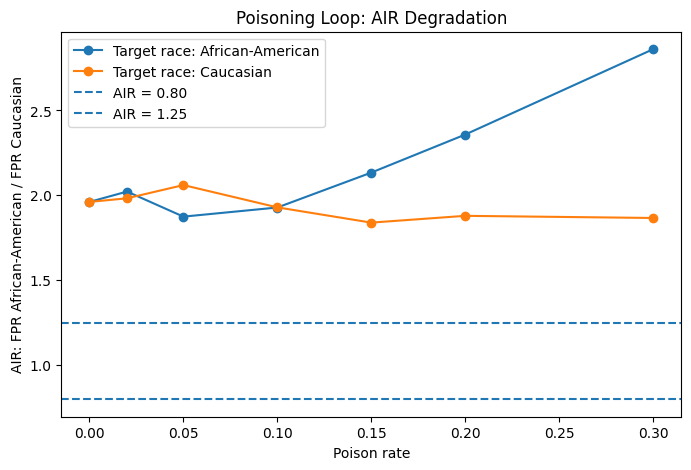

In [18]:
# Plot AIR degradation curves

plt.figure(figsize=(8, 5))

for target_race in poison_all["target_race"].unique():
    temp = poison_all[poison_all["target_race"] == target_race]

    plt.plot(
        temp["poison_rate"],
        temp["AIR_AA_over_CA"],
        marker="o",
        label=f"Target race: {target_race}"
    )

plt.axhline(0.80, linestyle="--", label="AIR = 0.80")
plt.axhline(1.25, linestyle="--", label="AIR = 1.25")
plt.xlabel("Poison rate")
plt.ylabel("AIR: FPR African-American / FPR Caucasian")
plt.title("Poisoning Loop: AIR Degradation")
plt.legend()
plt.show()

In [19]:
# Identify stealth zone

baseline_rows = poison_all[poison_all["poison_rate"] == 0.00][
    ["target_race", "test_auc", "AIR_AA_over_CA"]
].rename(columns={
    "test_auc": "baseline_auc",
    "AIR_AA_over_CA": "baseline_AIR"
})

poison_with_baseline = poison_all.merge(
    baseline_rows,
    on="target_race",
    how="left"
)

poison_with_baseline["auc_drop"] = (
    poison_with_baseline["baseline_auc"] - poison_with_baseline["test_auc"]
)

poison_with_baseline["air_change"] = (
    poison_with_baseline["AIR_AA_over_CA"] - poison_with_baseline["baseline_AIR"]
)

stealth = poison_with_baseline[
    (poison_with_baseline["poison_rate"] > 0) &
    (poison_with_baseline["auc_drop"] <= 0.02) &
    (
        (poison_with_baseline["AIR_AA_over_CA"] < 0.80) |
        (poison_with_baseline["AIR_AA_over_CA"] > 1.25)
    )
].copy()

print("Part 2: Stealth Zone")
print("Definition: poison_rate > 0, AUC drop <= 2 percentage points, and AIR outside [0.80, 1.25]")
print(stealth.round(3).to_string(index=False))

Part 2: Stealth Zone
Definition: poison_rate > 0, AUC drop <= 2 percentage points, and AIR outside [0.80, 1.25]
     target_race  poison_rate  test_auc  FPR_African_American  FPR_Caucasian  AIR_AA_over_CA  max_feature_PSI  baseline_auc  baseline_AIR  auc_drop  air_change
African-American         0.02     0.734                 0.270          0.133           2.022              0.0         0.735         1.961     0.000       0.061
African-American         0.05     0.735                 0.231          0.123           1.875              0.0         0.735         1.961    -0.000      -0.087
African-American         0.10     0.733                 0.200          0.104           1.929              0.0         0.735         1.961     0.002      -0.033
African-American         0.15     0.733                 0.153          0.072           2.134              0.0         0.735         1.961     0.002       0.173
African-American         0.20     0.728                 0.128          0.054           2

In [20]:
# PSI monitor check

psi_monitor_table = poison_all[
    ["target_race", "poison_rate", "max_feature_PSI"]
].copy()

psi_monitor_table["PSI_detected"] = psi_monitor_table["max_feature_PSI"] >= 0.10

print("Part 2: PSI Drift Monitor Check")
print(psi_monitor_table.round(4).to_string(index=False))

Part 2: PSI Drift Monitor Check
     target_race  poison_rate  max_feature_PSI  PSI_detected
African-American         0.00              0.0         False
African-American         0.02              0.0         False
African-American         0.05              0.0         False
African-American         0.10              0.0         False
African-American         0.15              0.0         False
African-American         0.20              0.0         False
African-American         0.30              0.0         False
       Caucasian         0.00              0.0         False
       Caucasian         0.02              0.0         False
       Caucasian         0.05              0.0         False
       Caucasian         0.10              0.0         False
       Caucasian         0.15              0.0         False
       Caucasian         0.20              0.0         False
       Caucasian         0.30              0.0         False


In [21]:
print("""
Part 2 Interpretation:

In this section, I simulated a label-flip poisoning attack. I tested two versions:
one targeting African-American defendants and one targeting Caucasian defendants.

The poisoning attack flips positive labels to 0 for the selected target race.
This follows the same general logic from the lecture poisoning loop, but extends
it to compare both racial targets.

The important part is not only whether AUC goes down. The more dangerous case is
the stealth zone, where AUC stays almost the same but AIR moves outside the
accepted fairness range of 0.80 to 1.25.

Because the clean baseline AIR may already be outside the [0.80, 1.25] range,
I interpret the stealth zone carefully. The key question is not only whether AIR
is outside the range, but whether poisoning changes AIR while AUC remains almost
unchanged.

The PSI monitor checks feature drift. Since this poisoning attack changes labels
and not feature values, a PSI-based feature drift monitor does not detect the
attack. This is an important security lesson: feature drift monitoring alone is
not enough to detect label poisoning.
""")


Part 2 Interpretation:

In this section, I simulated a label-flip poisoning attack. I tested two versions:
one targeting African-American defendants and one targeting Caucasian defendants.

The poisoning attack flips positive labels to 0 for the selected target race.
This follows the same general logic from the lecture poisoning loop, but extends
it to compare both racial targets.

The important part is not only whether AUC goes down. The more dangerous case is
the stealth zone, where AUC stays almost the same but AIR moves outside the
accepted fairness range of 0.80 to 1.25.

Because the clean baseline AIR may already be outside the [0.80, 1.25] range,
I interpret the stealth zone carefully. The key question is not only whether AIR
is outside the range, but whether poisoning changes AIR while AUC remains almost
unchanged.

The PSI monitor checks feature drift. Since this poisoning attack changes labels
and not feature values, a PSI-based feature drift monitor does not detect the
atta

In [22]:
# Part 3: Membership Inference Depth

# Membership inference tests whether an attacker can guess if a record
# was part of the model training set.


def membership_inference_confidence_auc(model, X_train_scaled, X_test_scaled):
    """
    Simple membership inference attack using confidence scores.

    Members = training records.
    Non-members = test records.

    The attack score is max predicted probability.
    Higher confidence suggests a higher chance of membership.
    """

    conf_train = model.predict_proba(X_train_scaled).max(axis=1)
    conf_test = model.predict_proba(X_test_scaled).max(axis=1)

    labels = np.concatenate([
        np.ones(len(conf_train)),
        np.zeros(len(conf_test))
    ])

    scores = np.concatenate([
        conf_train,
        conf_test
    ])

    mi_auc = roc_auc_score(labels, scores)

    return {
        "mi_auc": mi_auc,
        "conf_train": conf_train,
        "conf_test": conf_test,
        "labels": labels,
        "scores": scores
    }

In [23]:
# Run membership inference attack for both models

mi_lr = membership_inference_confidence_auc(lr, Xs_tr, Xs_te)
mi_gbt = membership_inference_confidence_auc(gbt, Xs_tr, Xs_te)

mi_summary = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "MI_AUC": mi_lr["mi_auc"],
        "train_conf_mean": mi_lr["conf_train"].mean(),
        "test_conf_mean": mi_lr["conf_test"].mean(),
        "confidence_gap": mi_lr["conf_train"].mean() - mi_lr["conf_test"].mean(),
        "train_auc": roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:, 1]),
        "test_auc": roc_auc_score(y_te, lr.predict_proba(Xs_te)[:, 1]),
    },
    {
        "model": "Gradient-Boosted Tree",
        "MI_AUC": mi_gbt["mi_auc"],
        "train_conf_mean": mi_gbt["conf_train"].mean(),
        "test_conf_mean": mi_gbt["conf_test"].mean(),
        "confidence_gap": mi_gbt["conf_train"].mean() - mi_gbt["conf_test"].mean(),
        "train_auc": roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:, 1]),
        "test_auc": roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:, 1]),
    }
])

mi_summary["generalization_gap"] = mi_summary["train_auc"] - mi_summary["test_auc"]

print("Part 3: Membership Inference Summary")
print(mi_summary.round(3).to_string(index=False))

Part 3: Membership Inference Summary
                model  MI_AUC  train_conf_mean  test_conf_mean  confidence_gap  train_auc  test_auc  generalization_gap
  Logistic Regression   0.498            0.658           0.659          -0.001      0.727     0.735              -0.008
Gradient-Boosted Tree   0.510            0.702           0.697           0.005      0.798     0.718               0.080


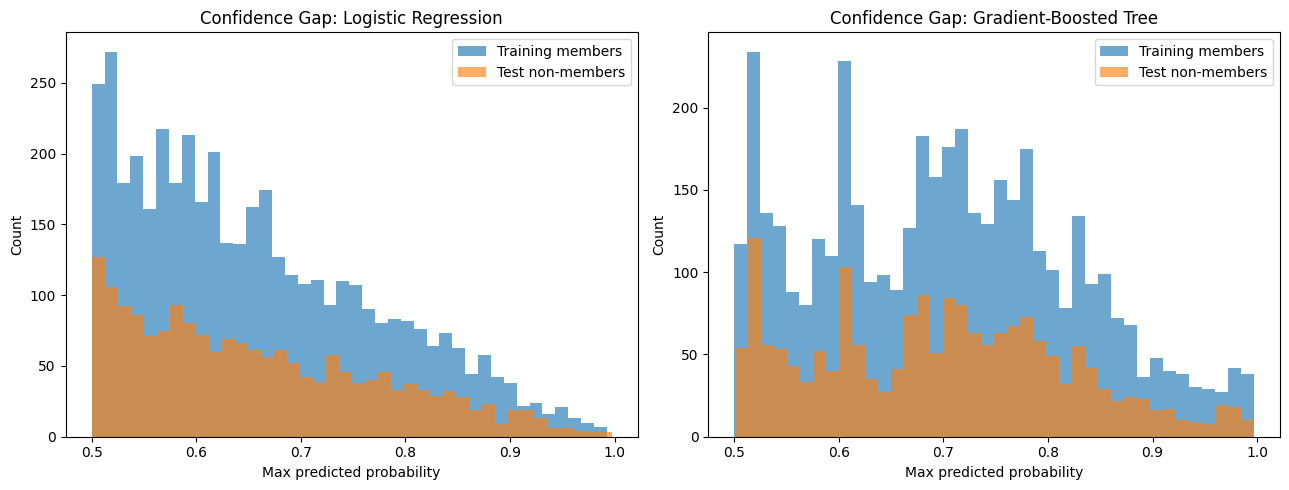

In [24]:
# Plot confidence-gap histograms side by side

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(mi_lr["conf_train"], bins=40, alpha=0.65, label="Training members")
axes[0].hist(mi_lr["conf_test"], bins=40, alpha=0.65, label="Test non-members")
axes[0].set_title("Confidence Gap: Logistic Regression")
axes[0].set_xlabel("Max predicted probability")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(mi_gbt["conf_train"], bins=40, alpha=0.65, label="Training members")
axes[1].hist(mi_gbt["conf_test"], bins=40, alpha=0.65, label="Test non-members")
axes[1].set_title("Confidence Gap: Gradient-Boosted Tree")
axes[1].set_xlabel("Max predicted probability")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

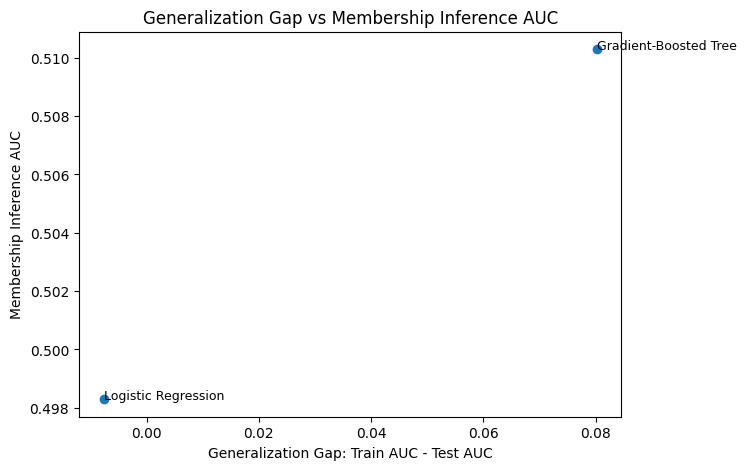

In [25]:
# Plot MI AUC vs generalization gap

plt.figure(figsize=(7, 5))
plt.scatter(mi_summary["generalization_gap"], mi_summary["MI_AUC"])

for _, row in mi_summary.iterrows():
    plt.text(
        row["generalization_gap"],
        row["MI_AUC"],
        row["model"],
        fontsize=9
    )

plt.xlabel("Generalization Gap: Train AUC - Test AUC")
plt.ylabel("Membership Inference AUC")
plt.title("Generalization Gap vs Membership Inference AUC")
plt.show()

In [26]:
# Logistic Regression regularization experiment

C_values = [0.01, 0.1, 1.0, 10.0]

reg_records = []

for C in C_values:
    lr_reg = LogisticRegression(max_iter=1000, C=C)
    lr_reg.fit(Xs_tr, y_tr)

    mi_reg = membership_inference_confidence_auc(lr_reg, Xs_tr, Xs_te)

    train_auc = roc_auc_score(y_tr, lr_reg.predict_proba(Xs_tr)[:, 1])
    test_auc = roc_auc_score(y_te, lr_reg.predict_proba(Xs_te)[:, 1])

    reg_records.append({
        "C": C,
        "MI_AUC": mi_reg["mi_auc"],
        "train_auc": train_auc,
        "test_auc": test_auc,
        "generalization_gap": train_auc - test_auc,
        "train_conf_mean": mi_reg["conf_train"].mean(),
        "test_conf_mean": mi_reg["conf_test"].mean(),
        "confidence_gap": mi_reg["conf_train"].mean() - mi_reg["conf_test"].mean()
    })

reg_table = pd.DataFrame(reg_records)

print("Part 3: LR Regularization and MI AUC")
print(reg_table.round(4).to_string(index=False))

Part 3: LR Regularization and MI AUC
    C  MI_AUC  train_auc  test_auc  generalization_gap  train_conf_mean  test_conf_mean  confidence_gap
 0.01  0.4973     0.7258    0.7321             -0.0064           0.6428          0.6443         -0.0015
 0.10  0.4983     0.7268    0.7342             -0.0074           0.6560          0.6574         -0.0014
 1.00  0.4983     0.7269    0.7345             -0.0077           0.6576          0.6590         -0.0014
10.00  0.4983     0.7269    0.7346             -0.0077           0.6577          0.6591         -0.0014


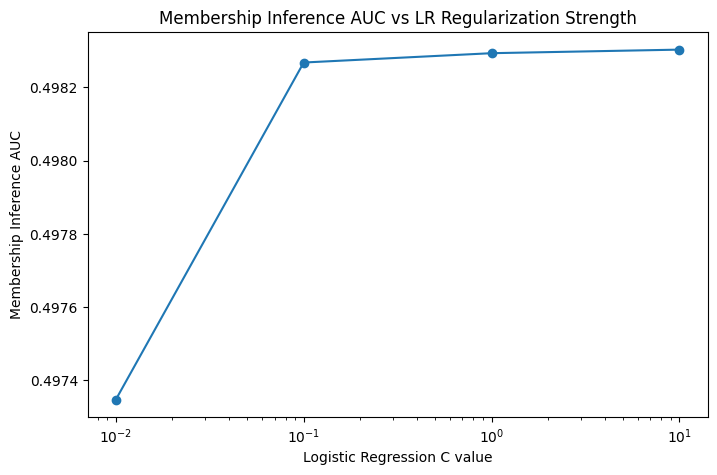

In [27]:
# Plot MI AUC vs C

plt.figure(figsize=(8, 5))
plt.plot(reg_table["C"], reg_table["MI_AUC"], marker="o")
plt.xscale("log")
plt.xlabel("Logistic Regression C value")
plt.ylabel("Membership Inference AUC")
plt.title("Membership Inference AUC vs LR Regularization Strength")
plt.show()

In [28]:
print("""
Part 3 Interpretation:

Membership inference tests whether an attacker can guess if a record was in the
training set. I use confidence scores because overfit models often give higher
confidence to training records than to test records.

The MI AUC shows how successful the attack is. A value near 0.50 means the attack
is close to random guessing. A higher value means more privacy leakage.

In my results, both models have MI AUC values close to 0.50, which suggests weak
membership inference risk in this experiment. The Gradient-Boosted Tree has a
larger generalization gap and a slightly higher MI AUC than Logistic Regression,
which is consistent with the lecture idea that overfitting can increase privacy
risk.

However, because I am only comparing two models, I cannot make a strong
statistical claim that the generalization gap predicts MI AUC. I can only say the
direction of the result is consistent with the expected pattern.

Finally, I vary the C value for Logistic Regression. Smaller C means stronger
regularization. The practical tradeoff is that stronger regularization may reduce
privacy leakage, but it can also slightly change model performance.
""")


Part 3 Interpretation:

Membership inference tests whether an attacker can guess if a record was in the
training set. I use confidence scores because overfit models often give higher
confidence to training records than to test records.

The MI AUC shows how successful the attack is. A value near 0.50 means the attack
is close to random guessing. A higher value means more privacy leakage.

In my results, both models have MI AUC values close to 0.50, which suggests weak
membership inference risk in this experiment. The Gradient-Boosted Tree has a
larger generalization gap and a slightly higher MI AUC than Logistic Regression,
which is consistent with the lecture idea that overfitting can increase privacy
risk.

However, because I am only comparing two models, I cannot make a strong
statistical claim that the generalization gap predicts MI AUC. I can only say the
direction of the result is consistent with the expected pattern.

Finally, I vary the C value for Logistic Regression. Smaller

In [29]:
# Part 4: Reflection and final summary

final_summary_rows = []

for _, row in pgd_hw_table.iterrows():
    final_summary_rows.append({
        "part": "PGD Evasion",
        "model_or_attack": row["model"],
        "setting": f"epsilon = {row['epsilon']}",
        "main_metric": "AIR",
        "value": row["AIR_AA_over_CA"]
    })

for _, row in poison_all.iterrows():
    final_summary_rows.append({
        "part": "Poisoning",
        "model_or_attack": f"Target: {row['target_race']}",
        "setting": f"poison rate = {row['poison_rate']}",
        "main_metric": "AIR",
        "value": row["AIR_AA_over_CA"]
    })

for _, row in mi_summary.iterrows():
    final_summary_rows.append({
        "part": "Membership Inference",
        "model_or_attack": row["model"],
        "setting": "confidence-based attack",
        "main_metric": "MI AUC",
        "value": row["MI_AUC"]
    })

final_homework_summary = pd.DataFrame(final_summary_rows)

print("Final Homework Summary")
print(final_homework_summary.round(3).to_string(index=False))

Final Homework Summary
                part          model_or_attack                 setting main_metric  value
         PGD Evasion      Logistic Regression          epsilon = 0.25         AIR  1.535
         PGD Evasion    Gradient-Boosted Tree          epsilon = 0.25         AIR  1.577
         PGD Evasion      Logistic Regression           epsilon = 0.5         AIR  1.411
         PGD Evasion    Gradient-Boosted Tree           epsilon = 0.5         AIR  1.426
         PGD Evasion      Logistic Regression           epsilon = 1.0         AIR  1.106
         PGD Evasion    Gradient-Boosted Tree           epsilon = 1.0         AIR  1.182
         PGD Evasion      Logistic Regression           epsilon = 2.0         AIR  1.000
         PGD Evasion    Gradient-Boosted Tree           epsilon = 2.0         AIR  1.000
           Poisoning Target: African-American       poison rate = 0.0         AIR  1.961
           Poisoning Target: African-American      poison rate = 0.02         AIR  2.02

In [30]:
# Highest-risk finding helper outputs

def distance_from_air_range(x):
    if pd.isna(x):
        return np.nan
    if 0.80 <= x <= 1.25:
        return 0
    if x < 0.80:
        return 0.80 - x
    return x - 1.25


pgd_hw_table["AIR_distance_from_range"] = pgd_hw_table["AIR_AA_over_CA"].apply(distance_from_air_range)
poison_all["AIR_distance_from_range"] = poison_all["AIR_AA_over_CA"].apply(distance_from_air_range)

worst_pgd = pgd_hw_table.sort_values("AIR_distance_from_range", ascending=False).head(1)
worst_poison = poison_all.sort_values("AIR_distance_from_range", ascending=False).head(1)
worst_mi = mi_summary.sort_values("MI_AUC", ascending=False).head(1)

print("Worst PGD Fairness Finding")
print(worst_pgd.round(3).to_string(index=False))

print("\nWorst Poisoning Fairness Finding")
print(worst_poison.round(3).to_string(index=False))

print("\nHighest Membership Inference Risk")
print(worst_mi.round(3).to_string(index=False))

Worst PGD Fairness Finding
                model  epsilon  FPR_African_American  FPR_Caucasian  AIR_AA_over_CA  AIR_distance_from_range
Gradient-Boosted Tree     0.25                 0.553          0.351           1.577                    0.327

Worst Poisoning Fairness Finding
     target_race  poison_rate  test_auc  FPR_African_American  FPR_Caucasian  AIR_AA_over_CA  max_feature_PSI  AIR_distance_from_range
African-American          0.3     0.731                 0.099          0.035            2.86              0.0                     1.61

Highest Membership Inference Risk
                model  MI_AUC  train_conf_mean  test_conf_mean  confidence_gap  train_auc  test_auc  generalization_gap
Gradient-Boosted Tree    0.51            0.702           0.697           0.005      0.798     0.718                0.08


In [31]:
print("""
Part 4 Reflection:

My highest-risk finding is that adversarial attacks can create serious reliability
or fairness problems even when normal model metrics do not fully reveal the issue.

For the PGD attack, the most important problem is that high epsilon values push
false positive rates very high. Even if AIR moves closer to 1.0, the model becomes
less useful because too many people are classified as high risk.

For the poisoning attack, the key risk is the stealth zone. AUC can remain almost
stable while AIR changes in a way that creates fairness concerns. This is dangerous
because a standard performance monitor may not flag the attack.

For membership inference, the risk is lower in this experiment because the MI AUC
values are close to random guessing. Still, the Gradient-Boosted Tree shows a
larger generalization gap and slightly higher MI AUC, so it should be monitored
more carefully.

A proactive mitigation would be adversarial training for evasion risk and stronger
data provenance controls for poisoning risk. For example, the system should log
who changed training labels and should audit suspicious label changes before
retraining.

A reactive mitigation would be continuous monitoring after deployment. This should
include FPR by race, AIR, prediction score distributions, poisoning checks, and
membership inference risk. If AIR moves outside the 0.80 to 1.25 range or false
positive rates increase sharply, the model should be paused for review.

The main tradeoff is that stronger security controls can reduce clean accuracy,
increase operational cost, or affect groups differently. Because of that, defenses
should be evaluated overall and by subgroup.
""")


Part 4 Reflection:

My highest-risk finding is that adversarial attacks can create serious reliability
or fairness problems even when normal model metrics do not fully reveal the issue.

For the PGD attack, the most important problem is that high epsilon values push
false positive rates very high. Even if AIR moves closer to 1.0, the model becomes
less useful because too many people are classified as high risk.

For the poisoning attack, the key risk is the stealth zone. AUC can remain almost
stable while AIR changes in a way that creates fairness concerns. This is dangerous
because a standard performance monitor may not flag the attack.

For membership inference, the risk is lower in this experiment because the MI AUC
values are close to random guessing. Still, the Gradient-Boosted Tree shows a
larger generalization gap and slightly higher MI AUC, so it should be monitored
more carefully.

A proactive mitigation would be adversarial training for evasion risk and stronger
data provena

# Final Individual Homework 05 Conclusion

In this notebook, I extended the Lecture 05 COMPAS security pipeline and tested three major adversarial machine learning risks: PGD evasion, label-flip poisoning, and membership inference.

For the PGD evasion audit, I tested epsilon values of 0.25, 0.5, 1.0, and 2.0 on both Logistic Regression and Gradient-Boosted Tree models. I reported FPR by race and AIR at each attack strength. In my results, AIR did not cross below 0.80. Instead, as epsilon increased, AIR moved closer to 1.0 because the false positive rate became very high for both racial groups. This means the attack still creates a serious reliability problem even if the fairness ratio appears more balanced.

For the poisoning loop, I compared two label-flip poisoning variants: one targeting African-American defendants and one targeting Caucasian defendants. I plotted AUC and AIR degradation and looked for a stealth zone where AUC stayed mostly stable while AIR moved outside the fairness range of 0.80 to 1.25. Because the baseline AIR may already be outside the fairness range, I interpret the stealth zone carefully by looking at whether poisoning changes AIR while AUC remains almost unchanged.

For the PSI monitor, the main finding is that feature-based PSI does not detect this poisoning attack because the attack changes labels rather than feature values. This shows that feature drift monitoring alone is not enough for security monitoring.

For membership inference, I computed MI AUC for both Logistic Regression and Gradient-Boosted Tree models. The MI AUC values were close to 0.50, meaning the attack was close to random guessing in this experiment. The Gradient-Boosted Tree had a larger generalization gap and slightly higher MI AUC, which is consistent with the idea that overfitting can increase privacy risk.

Overall, the most important lesson is that security, fairness, and robustness are connected. A model can look acceptable under normal accuracy metrics while still becoming unfair, unreliable, or vulnerable under adversarial conditions. In a high-stakes setting like COMPAS, the model should be monitored using fairness metrics, security tests, privacy-risk indicators, and data provenance controls before and after deployment.